# Part 1: Fine-Tune YOLOv12 for Glass Defect Detection

This notebook part demonstrates how to fine-tune the YOLOv12 object detection model on a custom dataset of glass-defect-detection. We'll go through environment setup, training, evaluation, and inference steps.

## Environment setup

### Step 1: Install Dependencies

We install the required packages:
- `ultralytics`: Official package to use YOLO models including the new YOLOv12.
- `supervision`: A toolset for evaluating and visualizing object detection results.

In [1]:
!pip install -qU ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00


### Step 2: Check GPU Availability

**NOTE:** **YOLOv12 leverages FlashAttention to speed up attention-based computations, but this feature requires an Nvidia GPU built on the Ampere architecture or newer—for example, GPUs like the RTX 3090, RTX 3080, or even the Nvidia L4 meet this requirement.**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### Step 3: Set Working Directory

This sets up the current working directory and store in a variable for use later when accessing files or saving models, and prints it for confirmation.

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
# HOME = os.getcwd()
HOME = "/content/drive/MyDrive/JCAIEAH-003/Notes and Hands On/Modul 4/Day 6/case-1"
os.chdir(HOME)
print(HOME)

/content/drive/MyDrive/JCAIEAH-003/Notes and Hands On/Modul 4/Day 6/case-1


### Step 4: Prepare the Dataset

Instructions:
1.	Go to Google Drive of this hands-on, and copy the dataset ZIP file (rock-paper-scissors-14.zip) into your My Drive.
You can place it under a new folder named datasets or directly under My Drive.
2.	In the left sidebar of Colab, go to the Files tab (📁 icon), and click “Mount Drive”.
3.	Once mounted, your Google Drive will be available under the path: /content/drive/MyDrive/.
4.	Find the path to your dataset file (right-click → Copy path).
5.	Replace the SOURCE PATH below with your copied path, then copy it into your working directory and unzip:

In [8]:
# Copy the dataset ZIP to the current working directory
# !scp -r /content/drive/MyDrive/datasets/glass-deffect-detection.zip . # REPLACE THE SOURCE PATH WITH YOURS -> /content/drive/MyDrive/datasets/rock-paper-scissors-14.zip

Unzips the dataset containing labeled images for rock, paper, and scissors.

In [9]:
# Unzip the dataset
!unzip ./glass-deffect-detection.zip

Archive:  ./glass-deffect-detection.zip
   creating: content/Glass-Defect-Detection-3/
   creating: content/Glass-Defect-Detection-3/train/
   creating: content/Glass-Defect-Detection-3/train/labels/
  inflating: content/Glass-Defect-Detection-3/train/labels/69_png_jpg.rf.9a1bbf8faf44d6cd69a33d46debd81f8.txt  
  inflating: content/Glass-Defect-Detection-3/train/labels/69_png_jpg.rf.24ee167d542cae42417e0ab250b5d0f1.txt  
  inflating: content/Glass-Defect-Detection-3/train/labels/89_png_jpg.rf.dbe785ffc98b75afeeafb00a09bd26fb.txt  
  inflating: content/Glass-Defect-Detection-3/train/labels/159_png_jpg.rf.aa4de809304a6f5a4ce1b08ccd46bbd8.txt  
  inflating: content/Glass-Defect-Detection-3/train/labels/646_png_jpg.rf.6a6b6a66f151f72ee6275a661ca15a1e.txt  
  inflating: content/Glass-Defect-Detection-3/train/labels/2_png_jpg.rf.bd024a52113b66df3d8650fea78fa715.txt  
  inflating: content/Glass-Defect-Detection-3/train/labels/177_png_jpg.rf.6928415e9c4833874df16bf2e7278254.txt  
  inflating: c

### Step 5: Dataset Overview

- Sets dataset location in a variable.
- Lists the contents of the dataset.
- Displays the data.yaml configuration file.

`data.yaml` tells YOLO where to find training/validation images, and which class labels are being used.


In [5]:
dataset_location = "./content/Glass-Defect-Detection-3"

In [6]:
!ls {dataset_location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [7]:
!cat {dataset_location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['defect', 'glass']

roboflow:
  workspace: capjamesg
  project: glass-defect-detection-fvbcu
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/capjamesg/glass-defect-detection-fvbcu/dataset/3

### Step 6: Download Pretrained YOLOv12 Weights

Downloads a pretrained YOLOv12 nano model (`yolov12n.pt`) to be fine-tuned.

In [14]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

--2026-05-05 10:20:38--  https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/99db71db-0946-4c10-94a0-b54baf471037?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-05T11%3A20%3A55Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-05T10%3A20%3A17Z&ske=2026-05-05T11%3A20%3A55Z&sks=b&skv=2018-11-09&sig=jlehthZbEwG4%2BU487qox6oGL6cI5ufxfljwHEYODN54%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3Nzk3NjczOCwibmJmIjoxNzc3OTc2NDM4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNv

### Step 7: Load Pretrained YOLO Model

Initializes the YOLO model using the downloaded weights.

In [15]:
from ultralytics import YOLO

model = YOLO('yolov12n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Step 8: Train the Model

Fine-tune YOLOv12 using our dataset for 20 epochs.
Parameters include:
- `data`: path to YAML config
- `epochs`: total number of training epochs
- `batch`: number of images per batch
- `imgsz`: input image size
- `patience`: early stopping if no improvement
- `save_period`: save model checkpoint every 5 epochs
- `val`: whether to validate
- `flipud`: probability of vertical flip augmentation

Trains YOLOv12 model on your dataset and saves it under runs/detect/train.


In [16]:
results = model.train(
        data=f'{dataset_location}/data.yaml', # Using 20 epochs for faster training
        epochs=20,
        batch=16,
        imgsz=640,
        exist_ok=True,
        patience=5,              # Early stopping if no improvement for 5 epochs
        save_period=5,           # Save checkpoints every 5 epochs
        val=True,                # Ensure validation is performed
        verbose=True,            # Show detailed output during training
        flipud=0.5,              # Augmentation using vertical flip probability
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./content/Glass-Defect-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

## Evaluation

### Step 9: Post-training Setup

Fix for character encoding and display directory structure for output artifacts.

In [17]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

# Lists training artifacts such as weights, result plots, and confusion matrix.
!ls {HOME}/runs/detect/train/

ls: cannot access '/content/drive/MyDrive/JCAIEAH-003/Notes': No such file or directory
ls: cannot access 'and': No such file or directory
ls: cannot access 'Hands': No such file or directory
ls: cannot access 'On/Modul': No such file or directory
ls: cannot access '4/Day': No such file or directory
ls: cannot access '6/case-1/runs/detect/train/': No such file or directory


### Step 10: Visualize Training Results

Display the confusion matrix and training result curves from the YOLO training run. The confusion matrix: how well the model distinguishes between classes.

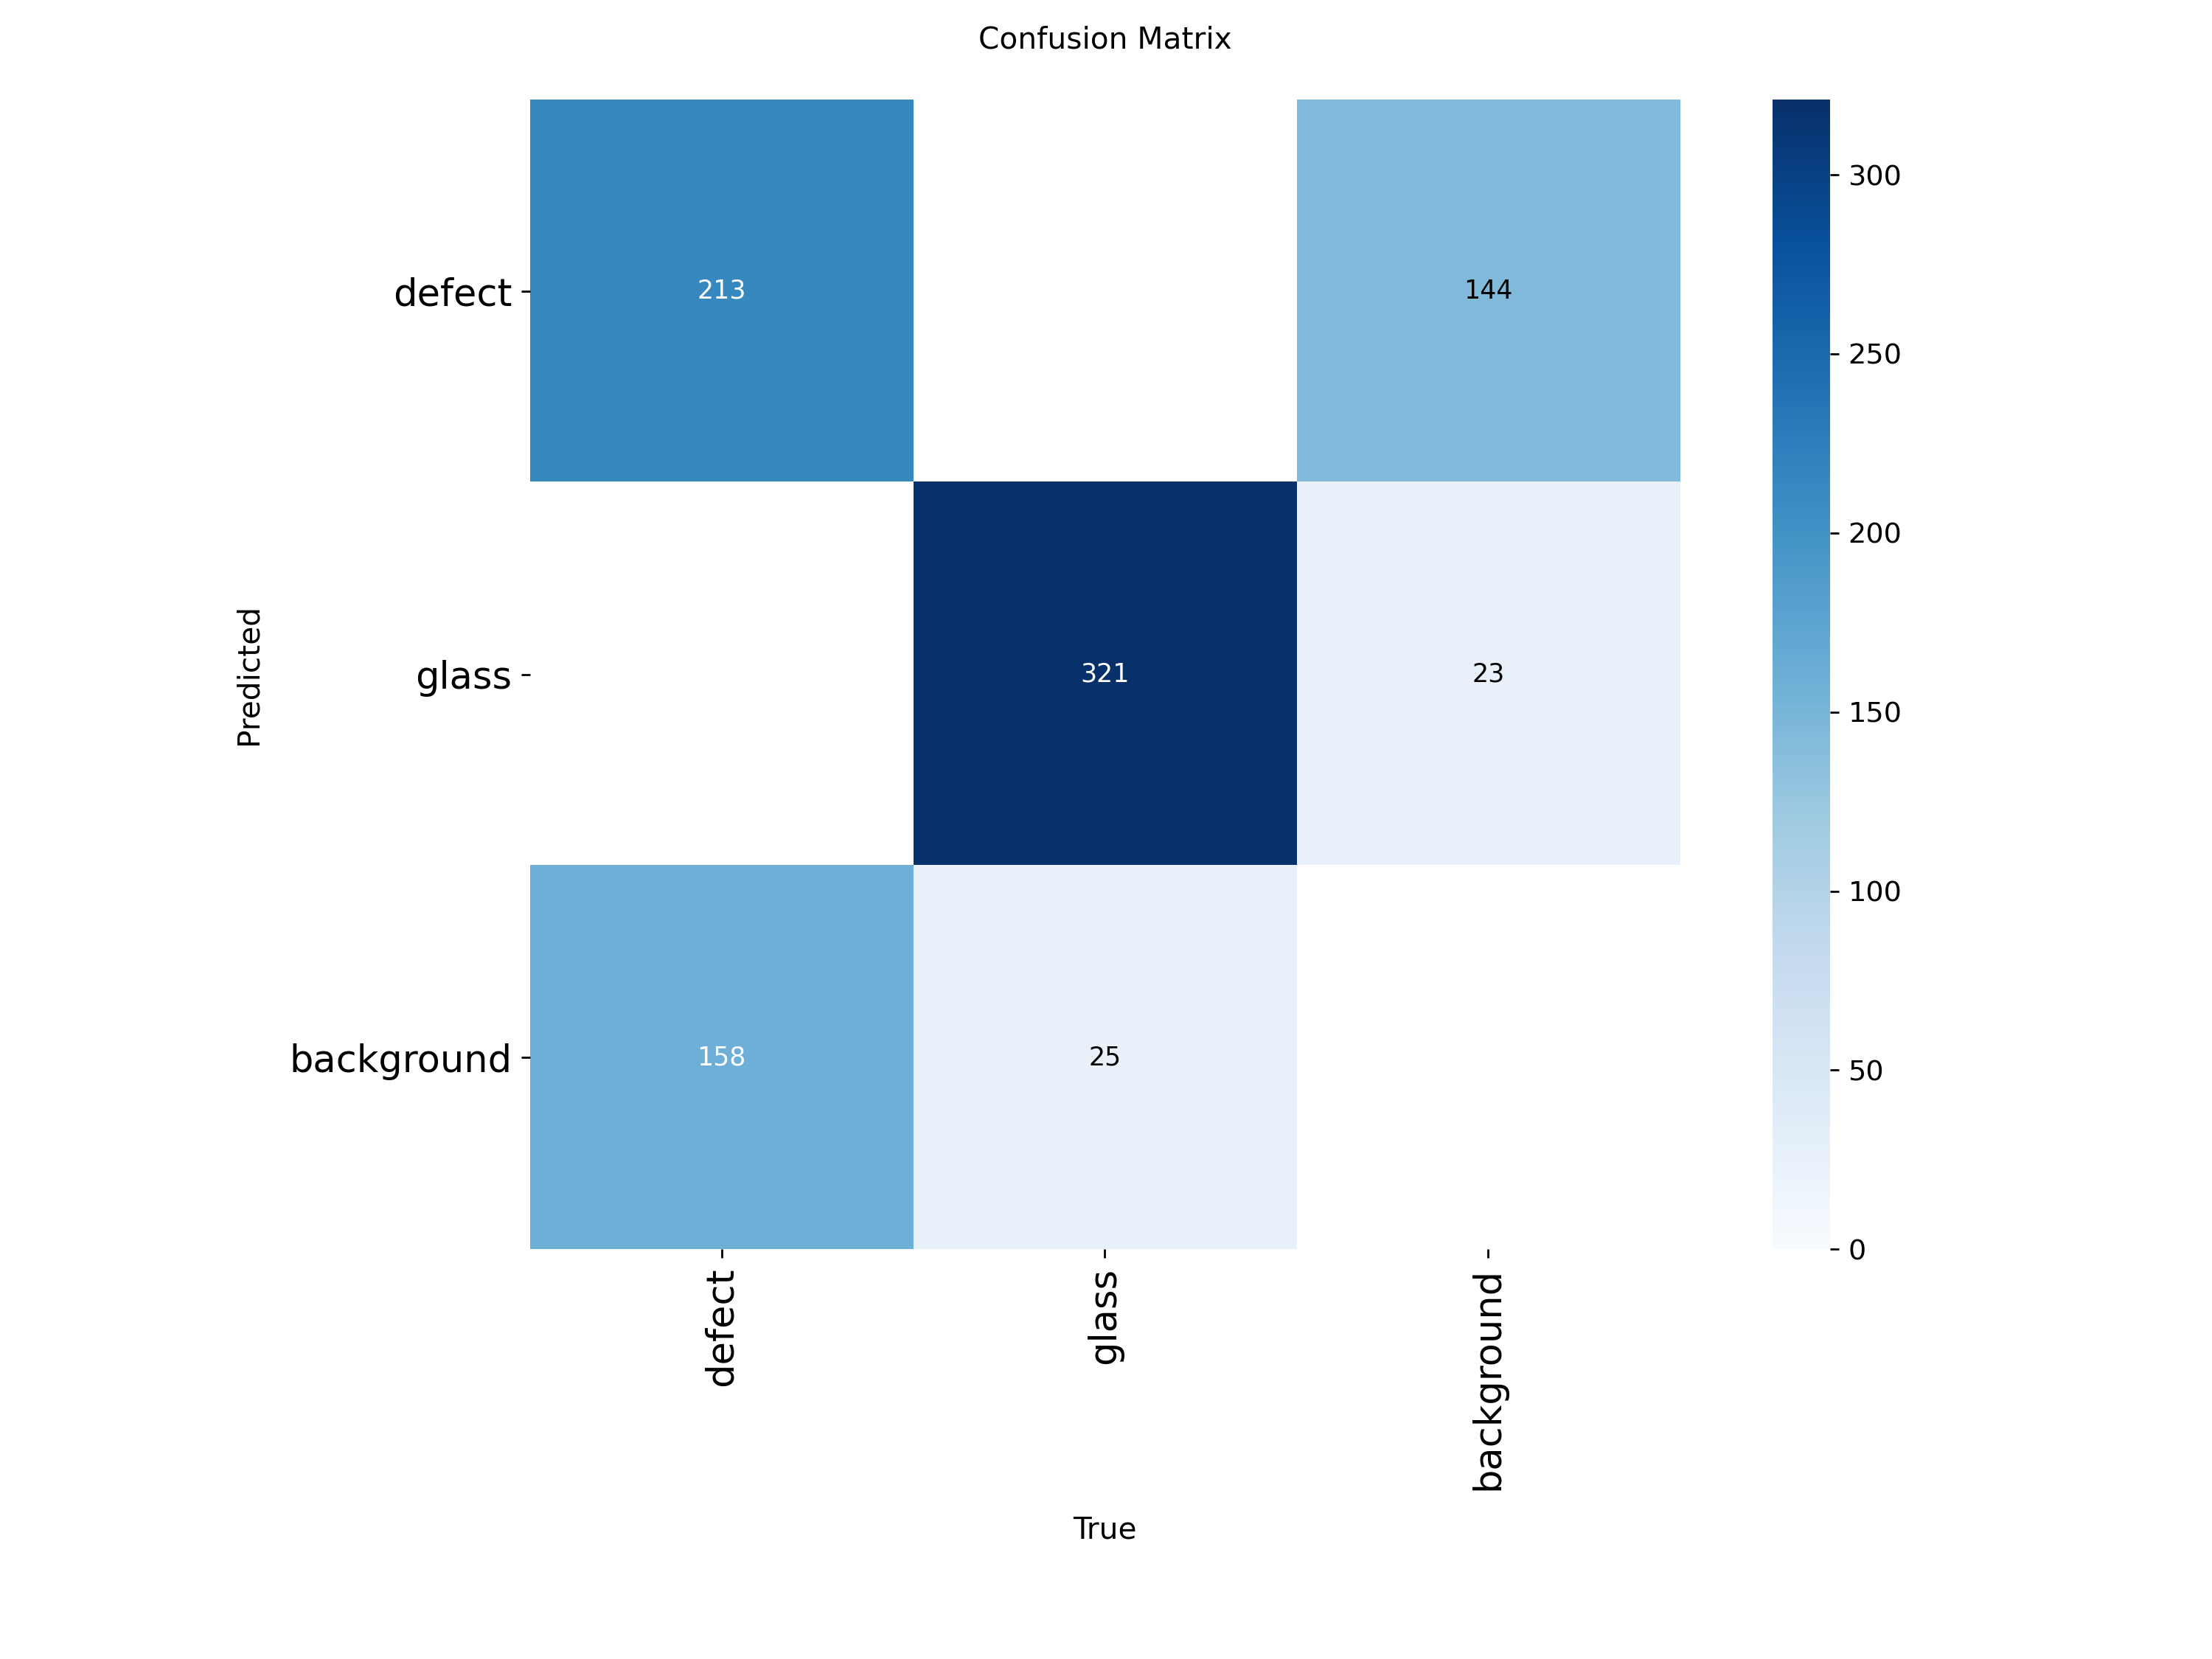

In [18]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

The training graph: loss, mAP, precision/recall over time.

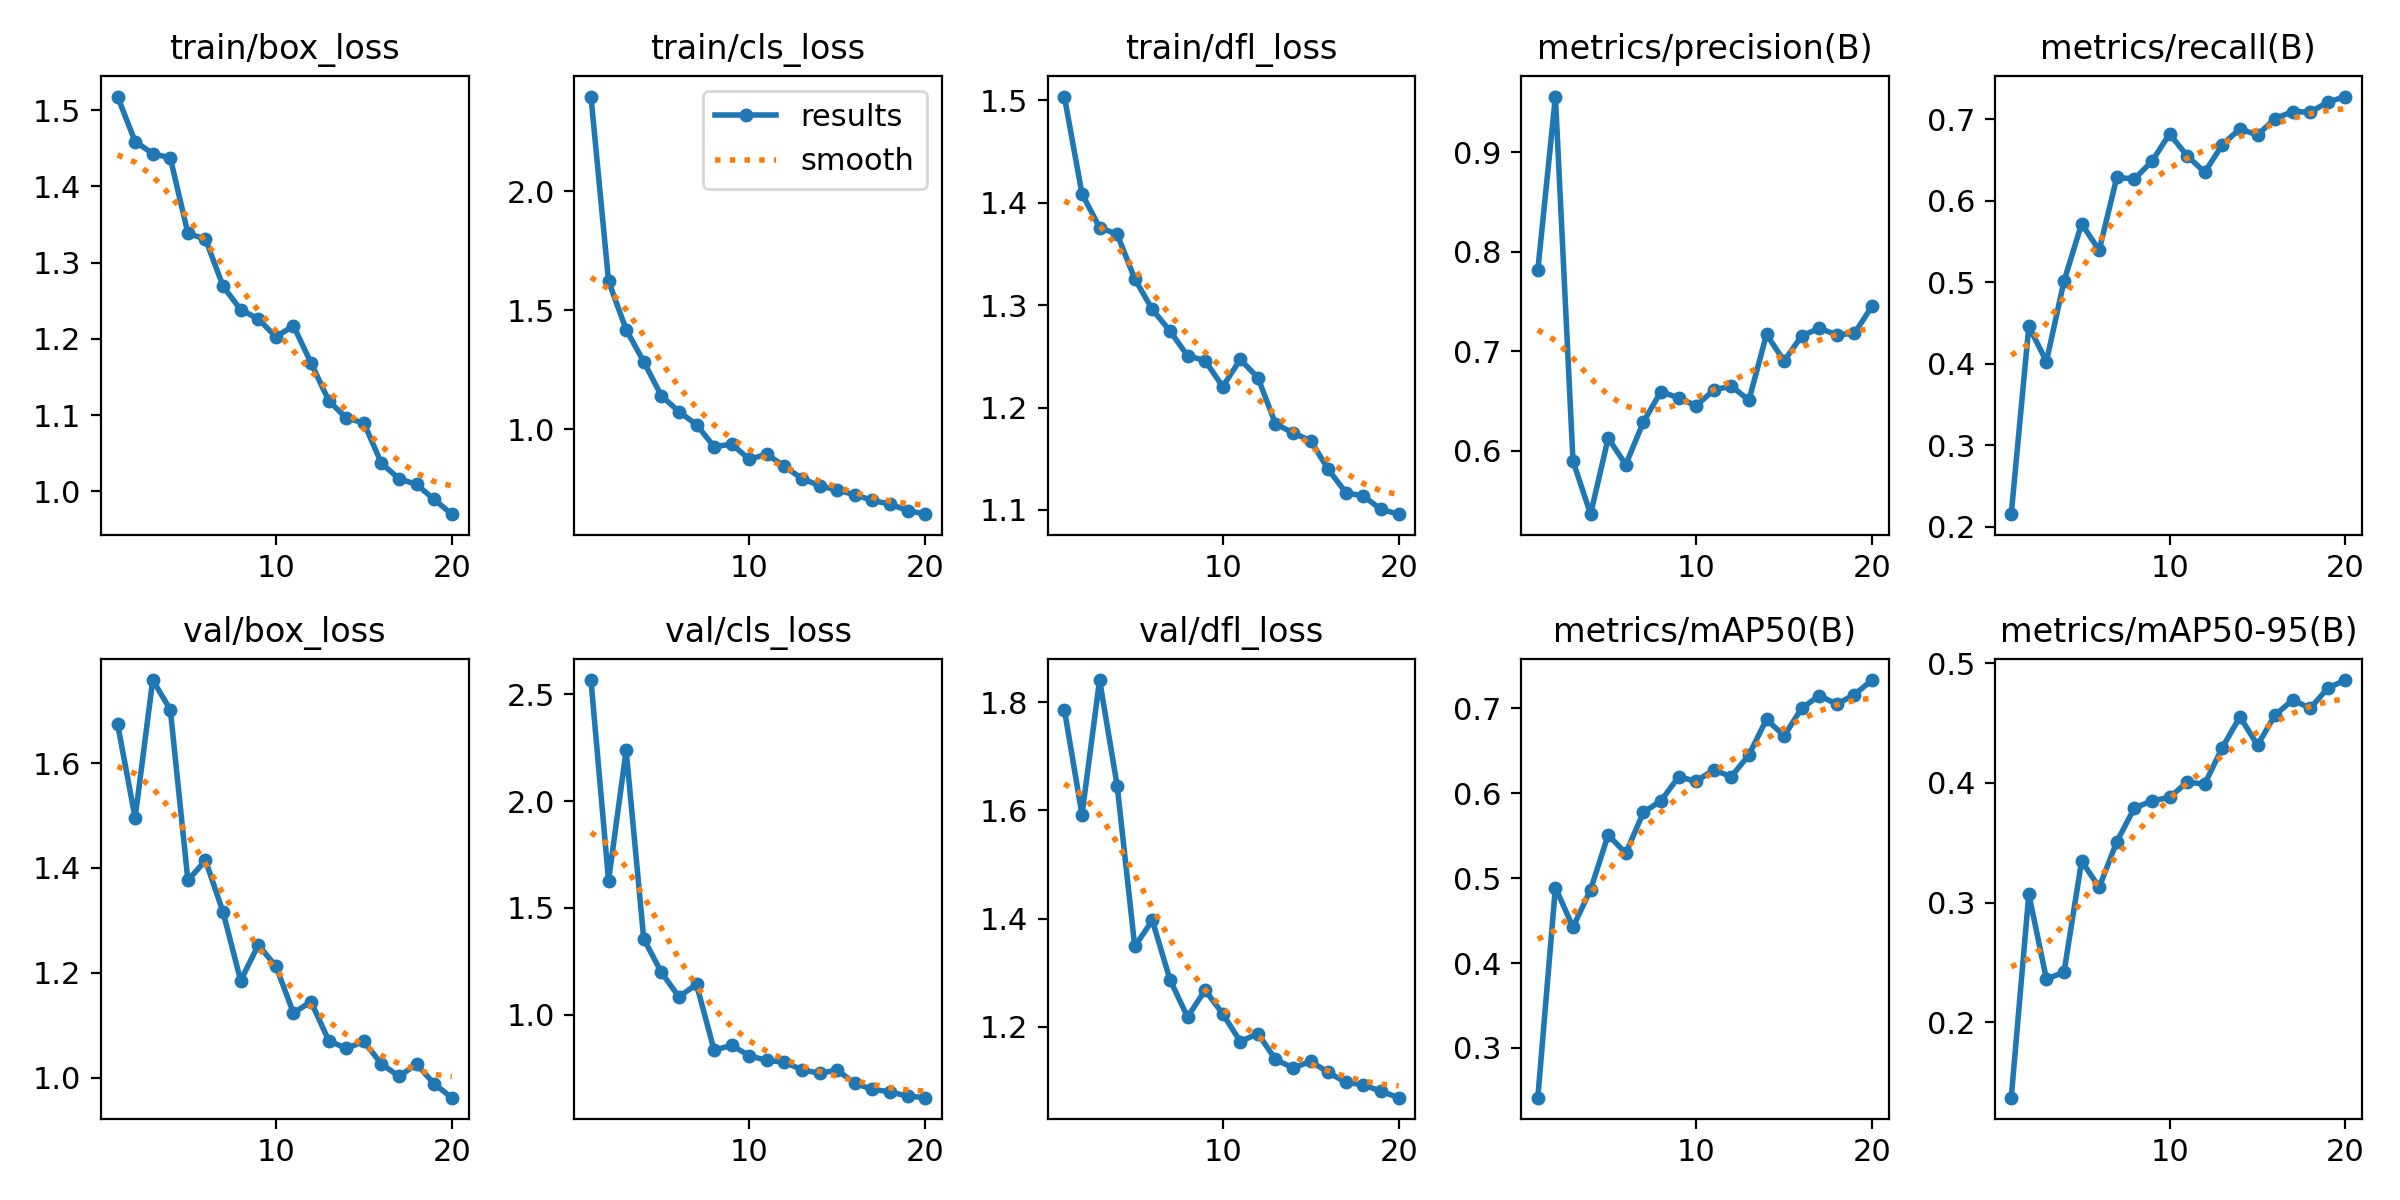

In [19]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

### Step 11: Load Test Dataset for Evaluation

Prepare test data using Supervision's dataset loader to evaluate model performance.

In [8]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=f"{dataset_location}/data.yaml"
)

ds.classes

['defect', 'glass']

### Step 12: Compute Mean Average Precision

Evaluate the trained model using mAP metrics (50, 75, and 50:95).

In [9]:
from ultralytics import YOLO
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


The mAP metrics are printed and the results are plotted.

In [10]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.4800790250301361
mAP 50 0.7017632722854614
mAP 75 0.48455682396888733


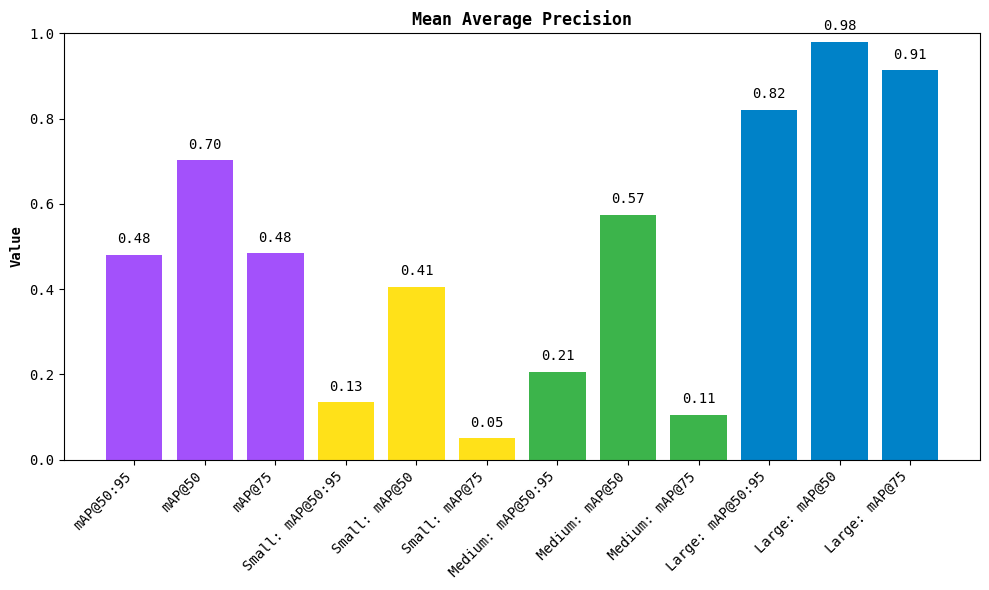

In [11]:
map.plot()

### Step 13: Inference on Random Test Image

Run the trained model on a random test image and visualize detections.

In [19]:
import supervision as sv

model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=f"{dataset_location}/data.yaml"
)

- Picks a random image.
- Runs the trained YOLOv12 model.
- Applies NMS (Non-Max Suppression) to clean overlapping boxes.

In [22]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

`plot_image` displays the final annotated image with predicted bounding boxes and labels.

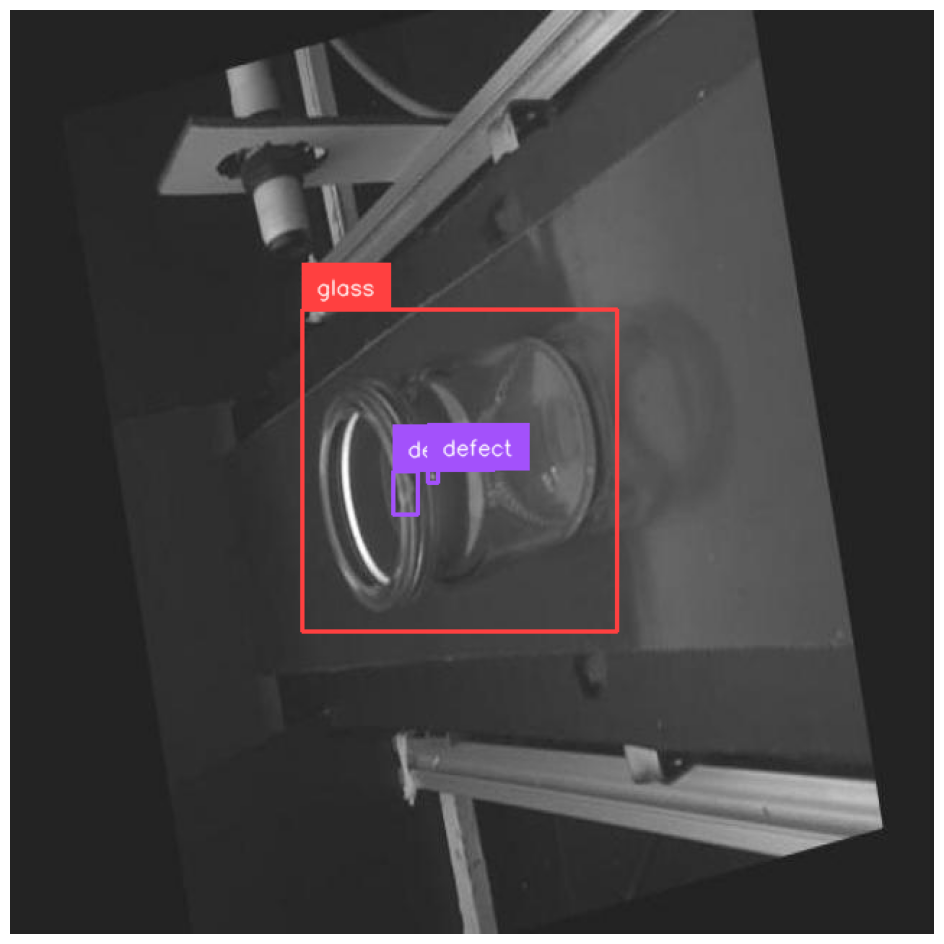

In [23]:
sv.plot_image(annotated_image)

# Part 2: Gradio Simulation for Glass Defect Detection

In [24]:
import gradio as gr
from ultralytics import YOLO
import numpy as np
import cv2
from PIL import Image
from collections import Counter

In [25]:
# Load your trained YOLO model
model = YOLO("./runs/detect/train/weights/best.pt")  # Ganti dengan path model kamu

# Define class names
class_names = ["defect", "glass"]

In [26]:
# Detection function with visual feedback
def detect_defect(image):
    results = model.predict(source=image, save=False, conf=0.3)[0]
    image_np = np.array(image)
    annotated_img = image_np.copy()

    detections = []
    class_counter = Counter()
    defect_found = False

    for box in results.boxes:
        cls_id = int(box.cls)
        label = class_names[cls_id]
        conf = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        class_counter[label] += 1
        if label == "defect":
            defect_found = True

        color = (0, 255, 0) if label == "glass" else (0, 0, 255)
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated_img, f"{label} ({conf:.2f})", (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    summary = "\n".join([f"{label}: {count}" for label, count in class_counter.items()])

    status_box = (
        ("⚠️ Defect(s) detected! Please inspect.", "error")
        if defect_found else
        ("✅ No defects found. Glass is acceptable.", "success")
    )

    return Image.fromarray(annotated_img), summary or "No objects detected.", status_box

In [27]:
def detect_defect(image):
    results = model.predict(source=image, save=False, conf=0.3)[0]
    image_np = np.array(image)
    annotated_img = image_np.copy()

    class_counter = Counter()
    defect_found = False

    for box in results.boxes:
        cls_id = int(box.cls.item())
        label = class_names[cls_id]
        conf = float(box.conf.item())

        # Fix: ambil koordinat box dengan benar
        coords = box.xyxy.cpu().numpy().astype(int)[0]
        x1, y1, x2, y2 = coords

        class_counter[label] += 1
        if label == "defect":
            defect_found = True

        color = (0, 255, 0) if label == "glass" else (0, 0, 255)
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated_img, f"{label} ({conf:.2f})", (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    summary = "\n".join([f"{label}: {count}" for label, count in class_counter.items()])

    # HTML-style status message
    if defect_found:
        status_html = (
            "<div style='padding:10px; background-color:#ffe5e5; color:#a30000; "
            "border-left: 6px solid #f00; font-weight:bold;'>⚠️ Defect(s) detected! Please inspect carefully.</div>"
        )
    else:
        status_html = (
            "<div style='padding:10px; background-color:#e6ffe6; color:#006600; "
            "border-left: 6px solid #0f0; font-weight:bold;'>✅ No defects found. Glass is acceptable.</div>"
        )

    return Image.fromarray(annotated_img), summary or "No objects detected.", status_html

# Gradio UI
with gr.Blocks() as demo:
    gr.Markdown("## 🧪 Glass Defect Detection System")
    gr.Markdown("Upload an image of a glass product to detect any defects.")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="Upload Glass Image")
            predict_btn = gr.Button("🔍 Run Detection")
        with gr.Column():
            output_image = gr.Image(type="pil", label="Detection Result")
            output_summary = gr.Textbox(label="Summary", lines=4)
            status_box = gr.HTML(label="Status Message")

    predict_btn.click(
        fn=detect_defect,
        inputs=input_image,
        outputs=[output_image, output_summary, status_box]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3a2e1190edce717d84.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
